## Vision Image finetuning

In [2]:
from fastai.vision.all import *

In [3]:
path = untar_data(URLs.PETS)
path.ls()

[Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/.DS_Store'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/models'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/annotations')]

In [4]:
files = get_image_files(path/"images")
files

(#7391) [Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/pug_52.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/basset_hound_112.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_193.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/shiba_inu_122.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_53.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Birman_167.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/leonberger_6.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_47.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/shiba_inu_136.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/saint_bernard_139.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Birman_173.jpg'), Path('/Users/Yashwa

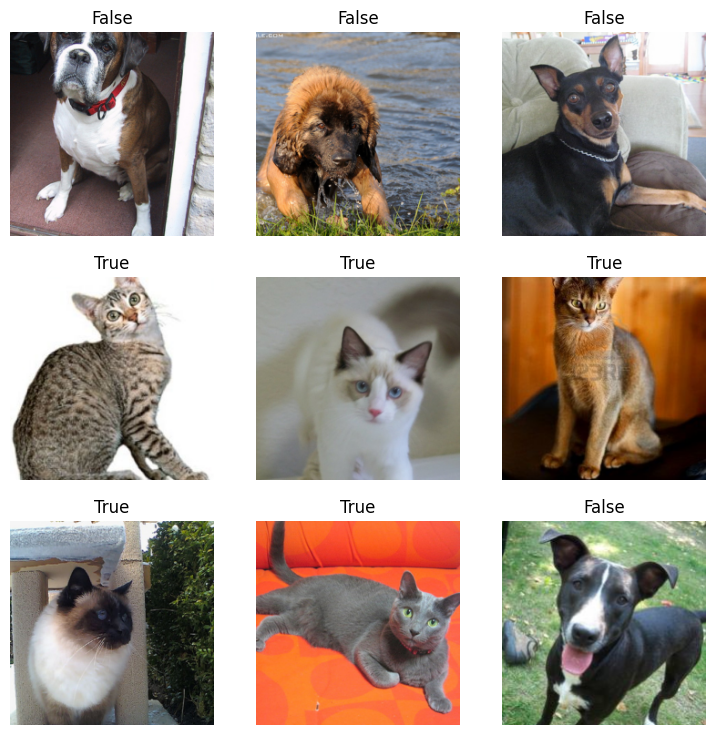

In [5]:
def label_func(f):
    return f[0].isupper()
    
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))
dls.show_batch()
print(dls)

<div></div>

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.165646,0.035749,0.015562,0.984438,00:32


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.056907,0.022949,0.007442,0.992558,00:39


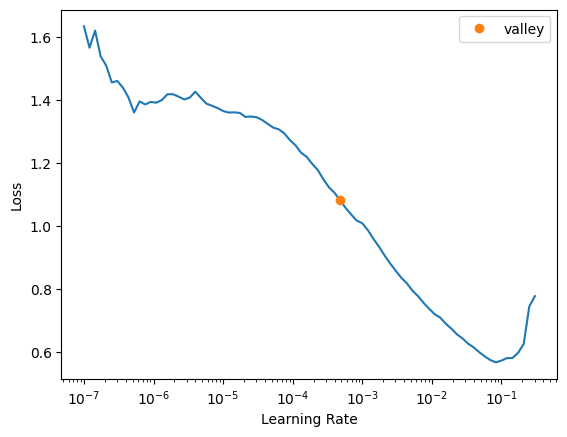

In [12]:
learn = vision_learner(dls, resnet18, metrics=[error_rate, accuracy])
learn.lr_find()
learn.fine_tune(1)

In [9]:
output1, output2, probs = learn.predict(files[3])


In [10]:
print((probs[1].item()*100))

99.99512434005737


In [11]:
learn.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      